# Iris: Regresión Logística frente a KNN

**Alumno:** Unai Urzainqui Perez. **Asignatura:** 5072. **Tarea Moodle:** 63325.

## Objetivo
Completar la práctica de clasificación del docente con las primeras dos medidas de Iris: longitud y anchura del sépalo, en centímetros. Entrenar Regresión Logística (`max_iter=200`) y KNN (`k=3`), representar sus fronteras lado a lado y explicar las diferencias.

## Preparación y datos
Iris contiene 150 flores, 50 de cada especie: setosa, versicolor y virginica. Se carga desde scikit-learn; no requiere descargar un CSV. Ejecutar todas las celdas en orden, desde esta carpeta y con el entorno indicado en `README.md`.

El notebook guarda `erabaki_mugak.png` y `resultados.json` junto a sus salidas. El informe separado es `txostena_beteta.md`.

**Cómo se evalúa:** los modelos se entrenan y evalúan sobre las mismas 150 flores. La accuracy describe el ajuste de entrenamiento; no mide capacidad de generalización. Se conservan las dos variables sin escalado, como en la plantilla docente.


In [1]:
%matplotlib inline
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams.update({"font.size": 11, "figure.dpi": 110})
print("Python:", sys.version.split()[0])
print({package: version(package) for package in ["numpy", "pandas", "matplotlib", "scikit-learn"]})

Python: 3.13.13
{'numpy': '2.5.3', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'scikit-learn': '1.9.1'}


## 1. Iris kargatu / Cargar Iris

In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target
assert X.shape == (150, 2) and len(y) == 150
print("X:", X.shape, "| y:", y.shape, "| klaseak:", list(iris.target_names))
print("Flores por clase:", dict(zip(iris.target_names, np.bincount(y))))

X: (150, 2) | y: (150,) | klaseak: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Flores por clase: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


## 2. Erabaki-mugak / Función de fronteras

El fondo muestra predicciones sobre una malla; los puntos muestran etiquetas observadas. El marcador y la leyenda permiten distinguir clases además del color.

In [3]:
def plot_decision_boundaries(clf, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    predicted = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    colors = ["#0072B2", "#E69F00", "#009E73"]
    ax.contourf(xx, yy, predicted, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=colors, alpha=0.22)
    for label, marker, color in zip(range(3), ["o", "^", "s"], colors):
        selected = y == label
        ax.scatter(X[selected, 0], X[selected, 1], marker=marker, color=color,
                   edgecolor="k", linewidth=0.5, s=35, label=iris.target_names[label])
    ax.set(title=title, xlabel="Sepal length (cm)", ylabel="Sepal width (cm)")
    ax.legend(title="Clase observada", fontsize=9)

## 3–4. LogReg eta KNN entrenatu / Ajustar los dos modelos

In [4]:
logreg = LogisticRegression(max_iter=200).fit(X, y)
knn = KNeighborsClassifier(n_neighbors=3).fit(X, y)
acc_lr = accuracy_score(y, logreg.predict(X))
acc_knn = accuracy_score(y, knn.predict(X))
results = pd.DataFrame({"Modelo": ["Logistic Regression", "KNN (k=3)"],
                        "Accuracy de entrenamiento": [acc_lr, acc_knn],
                        "Aciertos / 150": [int((logreg.predict(X) == y).sum()),
                                           int((knn.predict(X) == y).sum())]})
display(results.round(4))

,Modelo,Accuracy de entrenamiento,Aciertos / 150
0,Logistic Regression,0.8200,123
1,KNN (k=3),0.8533,128


## 5. Ikuskapen bisuala / Fronteras lado a lado

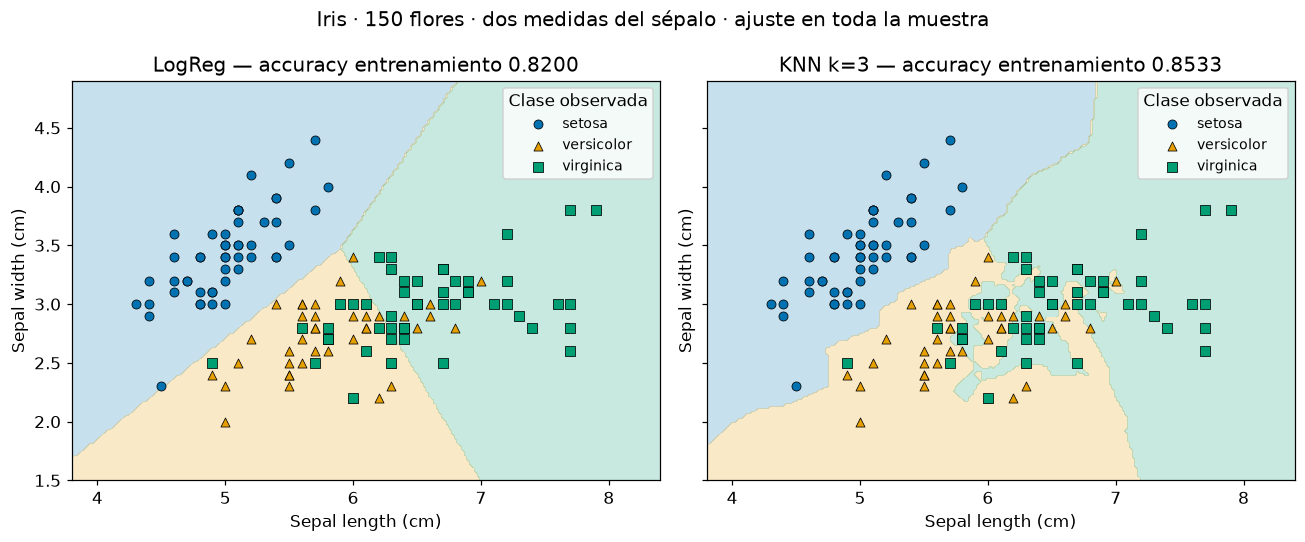

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
plot_decision_boundaries(logreg, X, y, axes[0],
                         f"LogReg — accuracy entrenamiento {acc_lr:.4f}")
plot_decision_boundaries(knn, X, y, axes[1],
                         f"KNN k=3 — accuracy entrenamiento {acc_knn:.4f}")
fig.suptitle("Iris · 150 flores · dos medidas del sépalo · ajuste en toda la muestra")
fig.tight_layout()
fig.savefig("erabaki_mugak.png", dpi=150)
plt.show()

## Comprobaciones

Matriz por modelo: filas = clase real, columnas = predicción; orden setosa, versicolor, virginica. La figura describe el ajuste; los errores se comprueban también numéricamente.

In [6]:
import json
from pathlib import Path

for name, model in [("LogReg", logreg), ("KNN k=3", knn)]:
    matrix = confusion_matrix(y, model.predict(X), labels=[0, 1, 2])
    assert matrix.sum() == 150
    print(name, "— matriz de entrenamiento:\n", matrix)
    assert matrix[0, 0] == 50, "Comprobar interpretación de setosa"
resultados = {
    "dataset": "sklearn.datasets.load_iris()", "n": int(len(y)),
    "features": ["sepal length (cm)", "sepal width (cm)"],
    "evaluation": "training; same 150 rows used by fit and predict",
    "logreg": {"max_iter": 200, "accuracy": float(acc_lr),
               "correct": int((logreg.predict(X) == y).sum()),
               "confusion_matrix": confusion_matrix(y, logreg.predict(X), labels=[0,1,2]).tolist()},
    "knn": {"n_neighbors": 3, "accuracy": float(acc_knn),
            "correct": int((knn.predict(X) == y).sum()),
            "confusion_matrix": confusion_matrix(y, knn.predict(X), labels=[0,1,2]).tolist()},
    "versions": {package: version(package) for package in ["numpy", "pandas", "matplotlib", "scikit-learn"]}
}
assert resultados["logreg"]["correct"] == 123 and resultados["knn"]["correct"] == 128
Path("resultados.json").write_text(json.dumps(resultados, ensure_ascii=False, indent=2)+"\n")


LogReg — matriz de entrenamiento:
 [[50  0  0]
 [ 0 37 13]
 [ 0 14 36]]
KNN k=3 — matriz de entrenamiento:
 [[50  0  0]
 [ 0 37 13]
 [ 0  9 41]]


859

## 6. Conclusiones y reflexión

1. **Forma de las fronteras:** Regresión Logística delimita regiones mediante rectas en este plano. KNN produce fronteras locales irregulares que dependen de la mayoría de los tres vecinos. El fondo indica la clase predicha, no una probabilidad ni confianza.
2. **Setosa y las otras clases:** en estas 150 flores ambos modelos aciertan las 50 setosa. Esa especie ocupa una región diferenciada en el gráfico. Versicolor y virginica se solapan con estas dos medidas y no se separan perfectamente. Esta observación se limita a la muestra representada.
3. **Vecinos muy pocos o muchos:** con k=1 se esperan fronteras más locales y sensibles a puntos aislados y ruido, con mayor riesgo de sobreajuste. Con k=50 se suavizan y pueden perder estructura local, aumentando el riesgo de subajuste. Son respuestas razonadas a una pregunta hipotética: esta ejecución utiliza k=3.

La accuracy de entrenamiento de KNN es mayor que la de LogReg en esta ejecución. No permite concluir cuál clasificará mejor flores nuevas. Para esa pregunta haría falta separar entrenamiento y test, o usar validación cruzada; cualquier transformación debería aprenderse dentro de cada entrenamiento.
